In [1]:
import pandas as pd
import numpy as np

In [85]:
from transformers import AutoTokenizer

ModuleNotFoundError: No module named 'transformers'

In [2]:
data = pd.read_csv(r'ielts_writing_dataset.csv')

In [3]:
data.head()

,Task_Type,Question,Essay,Examiner_Commen,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
0,1,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r...",NaN,NaN,NaN,NaN,NaN,5.5
1,2,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...,NaN,NaN,NaN,NaN,NaN,6.5
2,1,The bar chart below describes some changes abo...,The left chart shows the population change hap...,NaN,NaN,NaN,NaN,NaN,5.0
3,2,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...,NaN,NaN,NaN,NaN,NaN,5.5
4,1,The graph below shows the number of overseas v...,Information about the thousands of visits from...,NaN,NaN,NaN,NaN,NaN,7.0


In [4]:
data.describe()

,Task_Type,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
count,1435.000000,0.0,0.0,0.0,0.0,1435.000000
mean,1.552613,NaN,NaN,NaN,NaN,6.550174
std,0.497397,NaN,NaN,NaN,NaN,1.058237
min,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,1.000000,NaN,NaN,NaN,NaN,6.000000
50%,2.000000,NaN,NaN,NaN,NaN,6.500000
75%,2.000000,NaN,NaN,NaN,NaN,7.000000
max,2.000000,NaN,NaN,NaN,NaN,9.000000


In [5]:
data.isna().sum()

Task_Type                0
Question                 0
Essay                    0
Examiner_Commen       1373
Task_Response         1435
Coherence_Cohesion    1435
Lexical_Resource      1435
Range_Accuracy        1435
Overall                  0
dtype: int64

In [6]:
X = data[['Question' , 'Essay']]

In [7]:
X

,Question,Essay
0,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r..."
1,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...
2,The bar chart below describes some changes abo...,The left chart shows the population change hap...
3,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...
4,The graph below shows the number of overseas v...,Information about the thousands of visits from...
...,...,...
1430,Without capital punishment our lives are less ...,Serious crimes need capital punishment so that...
1431,Some people think that they can learn better b...,It is certainly said that learning is an ongoi...
1432,Nowadays people like to change their day by da...,popular hobbies rather than their individual a...
1433,Universities should allocate the same amount o...,"Yes, I do feel that universities should have a..."


In [8]:
y = data['Overall']

In [9]:
y

0       5.5
1       6.5
2       5.0
3       5.5
4       7.0
       ... 
1430    5.0
1431    5.0
1432    5.0
1433    5.0
1434    5.0
Name: Overall, Length: 1435, dtype: float64

In [10]:
y.describe()

count    1435.000000
mean        6.550174
std         1.058237
min         1.000000
25%         6.000000
50%         6.500000
75%         7.000000
max         9.000000
Name: Overall, dtype: float64

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    tokens = word_tokenize(text.lower())
    filtered = [stemmer.stem(w) for w in tokens if w.isalpha() and w not in stop_words]
    return ' '.join(filtered)


In [12]:
X.describe()

,Question,Essay
count,1435,1435
unique,402,1274
top,The graphs below show the types of music album...,The map shown provides a rough overview of a p...
freq,12,2


In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
combined_text = pd.concat([X['Question'], X['Essay']])

# Fit vectorizer on all text
vectorizer = CountVectorizer()
vectorizer.fit(combined_text)

# Transform col1 and col2 using the SAME vectorizer
bow_col1 = vectorizer.transform(X['Question'])
bow_col2 = vectorizer.transform(X['Essay'])

# Now compute cosine similarity row-wise
cos_sim = cosine_similarity(bow_col1, bow_col2).diagonal()
cos_sim = cos_sim.reshape(-1, 1)


# Add to DataFrame
X['cosine_similarity'] = cos_sim

print(X[['Question', 'Essay', 'cosine_similarity']])


                                               Question  \
0     The bar chart below describes some changes abo...   
1     Rich countries often give money to poorer coun...   
2     The bar chart below describes some changes abo...   
3     Rich countries often give money to poorer coun...   
4     The graph below shows the number of overseas v...   
...                                                 ...   
1430  Without capital punishment our lives are less ...   
1431  Some people think that they can learn better b...   
1432  Nowadays people like to change their day by da...   
1433  Universities should allocate the same amount o...   
1434  Modern medicine helps to live a longer life. D...   

                                                  Essay  cosine_similarity  
0     Between 1995 and 2010, a study was conducted r...           0.652084  
1     Poverty represents a worldwide crisis. It is t...           0.513792  
2     The left chart shows the population change hap...     

C:\Users\Siddharth\AppData\Local\Temp\ipykernel_8064\2106507126.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cosine_similarity'] = cos_sim


In [14]:
X.describe()

,cosine_similarity
count,1435.000000
mean,0.484822
std,0.113590
min,0.000000
25%,0.406138
50%,0.487950
75%,0.566822
max,0.756115


In [15]:
X = np.hstack([
    bow_col1.toarray(),         
    bow_col2.toarray(),         
    cos_sim                     
])

In [16]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size = 0.2)

In [17]:
from sklearn.linear_model import LinearRegression as LR
from sklearn.linear_model import Lasso as R1
from sklearn.linear_model import Ridge as R2
from sklearn.ensemble import RandomForestRegressor as RF

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

models = {
    'LinearRegression': LR(),
    'Lasso': R1(),
    'Ridge': R2(),
    'RandomForest': RF()
}

param_grids = {
    'LinearRegression': {
        'fit_intercept': [True, False]
    },
    'Lasso': {
        'alpha': [0.01, 0.1, 1.0, 10.0]
    },
    'Ridge': {
        'alpha': [0.01, 0.1, 1.0, 10.0]
    },
    'RandomForest': {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20]
    }
}

best_models = {}

for name in models:
    print(f"Running GridSearchCV for {name}")
    grid = GridSearchCV(
        estimator=models[name],
        param_grid=param_grids[name],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid.fit(x_train, y_train)
    
    best_models[name] = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_mse': -grid.best_score_,
        'test_mse': mean_squared_error(y_test, grid.best_estimator_.predict(x_test))
    }


Running GridSearchCV for LinearRegression
Running GridSearchCV for Lasso
Running GridSearchCV for Ridge
Running GridSearchCV for RandomForest


In [43]:
for model_name, model_info in best_models.items():
    print(f"Model: {model_name}")
    print(f"Best Params: {model_info['best_params']}")
    print(f"CV MSE: {model_info['cv_mse']:.4f}")
    print(f"Test MSE: {model_info['test_mse']:.4f}")
    print('-' * 40)


Model: LinearRegression
Best Params: {'fit_intercept': True}
CV MSE: 1.0891
Test MSE: 1.0359
----------------------------------------
Model: Lasso
Best Params: {'alpha': 0.01}
CV MSE: 0.9084
Test MSE: 0.8523
----------------------------------------
Model: Ridge
Best Params: {'alpha': 10.0}
CV MSE: 1.0260
Test MSE: 0.9702
----------------------------------------
Model: RandomForest
Best Params: {'max_depth': None, 'n_estimators': 100}
CV MSE: 0.7257
Test MSE: 0.8089
----------------------------------------


In [45]:
model = RF()

In [47]:
model.fit(x_train , y_train)

RandomForestRegressor()

In [75]:
y_pred = model.predict(x_test)

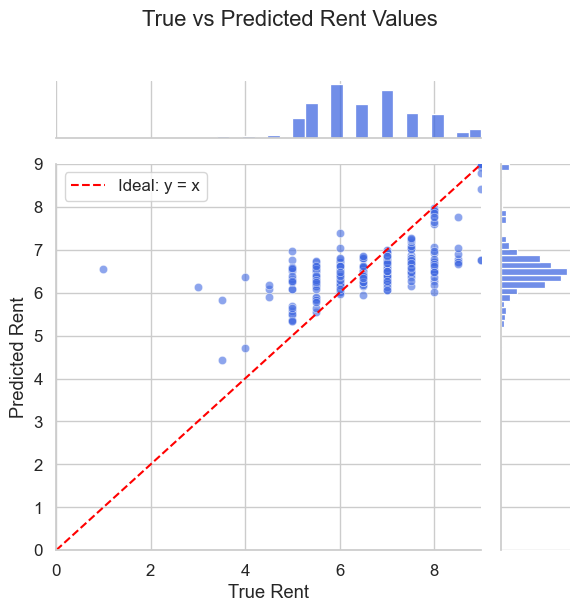

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
# y_test: true values, y_pred: predicted values (arrays or lists)

# Set aesthetic style
sns.set(style="whitegrid", font_scale=1.1)

# Create the joint plot with regression line and marginal histograms
g = sns.jointplot(
    x=y_test,
    y=y_pred,
    kind="scatter",   # Or "hex" for hexbin
    alpha=0.6,
    marginal_kws=dict(bins=30, fill=True),
    color='royalblue'
)

# Add identity line (perfect prediction line)
g.ax_joint.plot([0, 9], [0, 9], '--', color='red', label='Ideal: y = x')
g.ax_joint.legend()

# Set axis labels and limits
g.set_axis_labels("True Rent", "Predicted Rent")
g.ax_joint.set_xlim(0, 9)
g.ax_joint.set_ylim(0, 9)

plt.suptitle("True vs Predicted Rent Values", y=1.02)
plt.tight_layout()
plt.show()


In [83]:
model.score(x_test , y_test)

0.38995822453884865

In [93]:
import pickle
with open (essay_score) as f:
    pickle.dump(f,model)

NameError: name 'essay_score' is not defined